# K-Means Initialization Effect Analysis

**Dataset:** `kmeans_init.csv`  
**Objective:** Understand how K-Means initialization affects clustering results.

## Tasks
- Run K-Means multiple times with different `random_state` values
- Keep **K fixed** at `K = 3`
- Compare cluster assignments, inertia, and centroids
- Answer:
  1. Do cluster results change across runs?
  2. Why is K-Means sensitive to initialization?
  3. How can this issue be minimized?


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Show all columns
pd.set_option("display.max_columns", None)


## 1. Load the dataset

In [2]:
# Load dataset
df = pd.read_csv("kmeans_init.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (300, 2)


,Feature1,Feature2
0,-7.112997,-6.782198
1,-4.353466,-8.579587
2,7.833021,-12.434260
3,-8.412982,-5.201894
4,9.360637,-10.596066


## 2. Basic data check

K-Means works with numerical features. Here, we select all numeric columns from the dataset.

In [3]:
# Select numeric columns only
X = df.select_dtypes(include=[np.number])

print("Numeric columns used for clustering:")
print(X.columns.tolist())

X.head()


Numeric columns used for clustering:
['Feature1', 'Feature2']


,Feature1,Feature2
0,-7.112997,-6.782198
1,-4.353466,-8.579587
2,7.833021,-12.434260
3,-8.412982,-5.201894
4,9.360637,-10.596066


## 3. Scale the data

Scaling is important because K-Means uses distance. If one feature has a large range, it can dominate the clustering result.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (300, 2)


## 4. Run K-Means multiple times with different random states

We keep `K = 3` fixed and change only the initialization using different `random_state` values.

In [6]:
K = 3
random_states = [0, 1, 2, 3, 4, 5, 10, 20, 42, 99]

results = []
labels_dict = {}
centroids_dict = {}

for rs in random_states:
    kmeans = KMeans(
        n_clusters=K,
        random_state=rs,
        n_init=1
    )

    labels = kmeans.fit_predict(X_scaled)

    labels_dict[rs] = labels
    centroids_dict[rs] = kmeans.cluster_centers_

    results.append({
        "random_state": rs,
        "inertia": kmeans.inertia_,
        "iterations": kmeans.n_iter_
    })

results_df = pd.DataFrame(results)
results_df


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

,random_state,inertia,iterations
0,0,177.991789,10
1,1,177.991789,7
2,2,178.095162,7
3,3,177.991789,8
4,4,177.991789,7
5,5,178.095162,10
6,10,177.991789,10
7,20,178.095162,5
8,42,178.095162,9
9,99,177.991789,7


## 5. Compare inertia values

Lower inertia means points are closer to their assigned cluster centroids. Different initialization can lead to different local solutions.

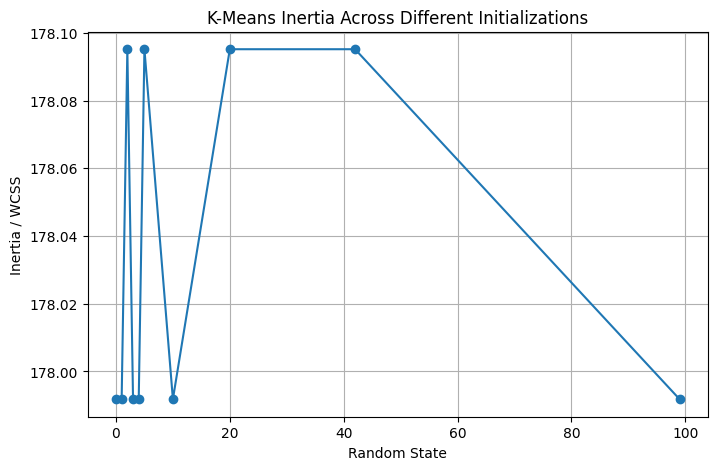

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["random_state"], results_df["inertia"], marker="o")
plt.xlabel("Random State")
plt.ylabel("Inertia / WCSS")
plt.title("K-Means Inertia Across Different Initializations")
plt.grid(True)
plt.show()


## 6. Compare cluster assignments using Adjusted Rand Index

The cluster label numbers may change across runs. For example, cluster `0` in one run may be cluster `2` in another run.  
So we use **Adjusted Rand Index (ARI)** to compare whether the actual grouping structure is similar.

- ARI close to **1** means cluster assignments are highly similar.
- ARI close to **0** means cluster assignments are very different.


In [8]:
base_rs = random_states[0]
base_labels = labels_dict[base_rs]

ari_results = []

for rs in random_states:
    ari = adjusted_rand_score(base_labels, labels_dict[rs])
    ari_results.append({
        "compared_with_base_random_state": base_rs,
        "random_state": rs,
        "adjusted_rand_index": ari
    })

ari_df = pd.DataFrame(ari_results)
ari_df


,compared_with_base_random_state,random_state,adjusted_rand_index
0,0,0,1.000000
1,0,1,1.000000
2,0,2,0.944247
3,0,3,1.000000
4,0,4,1.000000
5,0,5,0.944247
6,0,10,1.000000
7,0,20,0.944247
8,0,42,0.944247
9,0,99,1.000000


## 7. Visualize clustering results for selected runs

Because this dataset has two numeric features, we can directly plot the clusters.

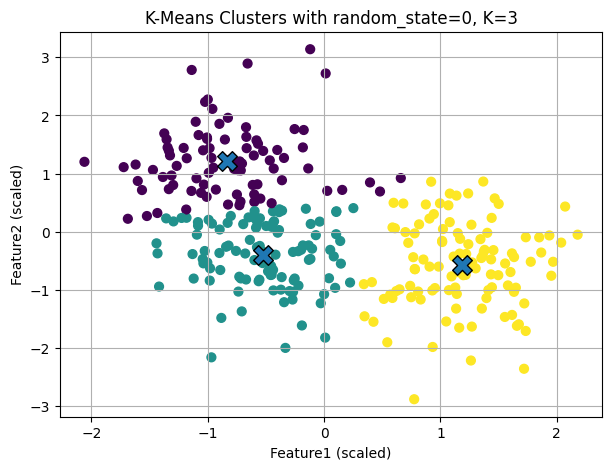

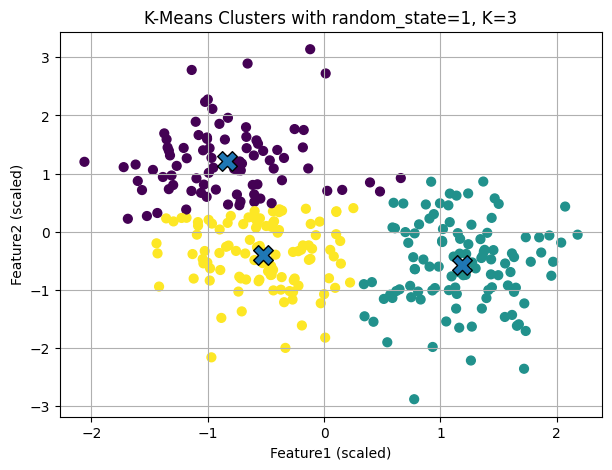

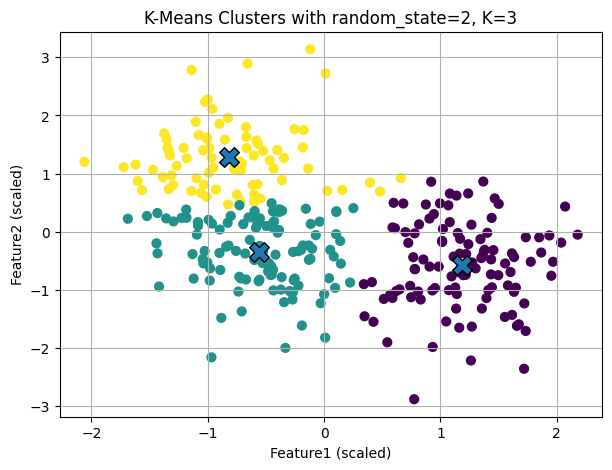

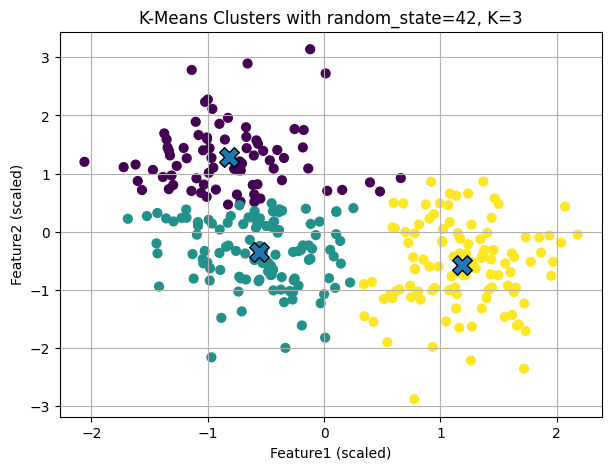

In [9]:
# Select a few random states for visual comparison
selected_states = [0, 1, 2, 42]

for rs in selected_states:
    labels = labels_dict[rs]
    centroids = centroids_dict[rs]

    plt.figure(figsize=(7, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=40)
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=200,
        edgecolor="black"
    )
    plt.xlabel(X.columns[0] + " (scaled)")
    plt.ylabel(X.columns[1] + " (scaled)")
    plt.title(f"K-Means Clusters with random_state={rs}, K={K}")
    plt.grid(True)
    plt.show()


## 8. Add cluster outputs back to the dataset

This helps compare how the same data point is assigned across different runs.

In [10]:
comparison_df = df.copy()

for rs in selected_states:
    comparison_df[f"cluster_rs_{rs}"] = labels_dict[rs]

comparison_df.head(10)


,Feature1,Feature2,cluster_rs_0,cluster_rs_1,cluster_rs_2,cluster_rs_42
0,-7.112997,-6.782198,1,2,1,1
1,-4.353466,-8.579587,1,2,1,1
2,7.833021,-12.434260,2,1,0,2
3,-8.412982,-5.201894,0,0,2,0
4,9.360637,-10.596066,2,1,0,2
5,-9.930595,-10.103101,1,2,1,1
6,2.476060,-9.989388,2,1,0,2
7,0.992979,-5.798768,2,1,0,2
8,-10.084331,-9.720327,1,2,1,1
9,-7.863049,-2.124298,0,0,2,0


## 9. Use better initialization with multiple starts

`n_init` runs K-Means multiple times with different centroid seeds and keeps the best result based on inertia. This reduces the risk of a poor initialization.

In [11]:
kmeans_stable = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

stable_labels = kmeans_stable.fit_predict(X_scaled)

print("Stable K-Means inertia:", kmeans_stable.inertia_)
print("Number of iterations:", kmeans_stable.n_iter_)


Stable K-Means inertia: 177.99178923089875
Number of iterations: 11


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=stable_labels, s=40)
plt.scatter(
    kmeans_stable.cluster_centers_[:, 0],
    kmeans_stable.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)
plt.xlabel(X.columns[0] + " (scaled)")
plt.ylabel(X.columns[1] + " (scaled)")
plt.title("K-Means with n_init=10")
plt.grid(True)
plt.show()


# Answers to Questions

## 1. Do cluster results change across runs?

Cluster results **may change** across runs because K-Means starts with randomly selected initial centroids.  
If the initial centroids are different, the algorithm may move toward different final centroid positions.

In this notebook, compare:
- The inertia table
- The ARI table
- The cluster plots

If inertia and ARI values are almost the same, the dataset has a clear cluster structure.  
If they differ, initialization is affecting the clustering result.

## 2. Why is K-Means sensitive to initialization?

K-Means is sensitive to initialization because it follows an iterative process:

1. Choose initial centroids
2. Assign each point to the nearest centroid
3. Recalculate centroids
4. Repeat until stable

If the first centroids are poorly placed, K-Means can converge to a **local minimum** instead of the best global clustering solution.

## 3. How can this issue be minimized?

This issue can be minimized by:

1. Using `n_init` with multiple runs  
   - Example: `n_init=10`
   - K-Means runs several times and selects the best result.

2. Using `k-means++` initialization  
   - This is the default in scikit-learn.
   - It chooses better initial centroids than pure random selection.

3. Scaling the data  
   - Scaling prevents one feature from dominating distance calculation.

4. Running K-Means with multiple random states  
   - This helps check whether the clustering result is stable.

## Final Conclusion

If different random states produce similar clusters and similar inertia, the dataset has a stable cluster structure.  
If results change significantly, initialization has a strong effect and the model should use multiple initializations such as `n_init=10` or more.
